# Data Processing and Manipulation with Pandas and NumPy

Welcome to this workshop! In this session, we'll cover:

- Data processing and manipulation using **Pandas**
- Performing equivalent operations using **NumPy**
- Utilizing Pandas' native plotting features for quick data exploration

## Table of Contents

1. [Introduction](#introduction)
2. [Data Loading and Exploration](#data_loading)
3. [Data Manipulation with Pandas](#data_manipulation_pandas)
4. [Equivalent Operations with NumPy](#equivalent_numpy)
5. [Pandas Native Plotting](#pandas_plotting)
6. [Conclusion](#conclusion)

---

<a id='data_loading'></a>
## 1. Data Loading and Exploration

We'll start by loading a sample dataset and exploring its contents.

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

### Loading the Dataset

- We'll use the **Titanic** dataset for demonstration.
- This dataset contains information about the passengers on the Titanic.

In [ ]:
# Load the Titanic dataset from a URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display the first few rows
df.head()

### Data Overview

- **Columns**:
  - `PassengerId`, `Survived`, `Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, `Embarked`.
- Use `df.info()` and `df.describe()` to get more details.

In [ ]:
# Get information about the dataset
df.info()

In [ ]:
# Get statistical summary
df.describe()

<a id='data_manipulation_pandas'></a>
## 2. Data Manipulation with Pandas

We'll perform common data manipulation tasks using Pandas.

### Selecting Columns

- Select a single column: `df['Age']`
- Select multiple columns: `df[['Age', 'Fare']]`

In [ ]:
# Select 'Age' and 'Fare' columns
df_subset = df[['Age', 'Fare']]
df_subset.head()

### Filtering Rows

- Filter rows where `Age` > 30: `df[df['Age'] > 30]`
- Filter rows where `Sex` is `female`: `df[df['Sex'] == 'female']`

In [ ]:
# Filter passengers older than 30
df_over_30 = df[df['Age'] > 30]
df_over_30.head()

### GroupBy Operations

- Calculate mean age by sex: `df.groupby('Sex')['Age'].mean()`
- Count survivors by passenger class: `df.groupby('Pclass')['Survived'].sum()`

In [6]:
# Mean age by sex
mean_age_by_sex = df.groupby('Sex')['Age'].mean()
mean_age_by_sex

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [ ]:
df.groupby('Pclass')['Survived'].sum()


### Adding New Columns

- Create a new column `FamilySize` as the sum of `SibSp` and `Parch`.

In [ ]:
# Add a new column 'FamilySize'
df['FamilySize'] = df['SibSp'] + df['Parch']
df[['SibSp', 'Parch', 'FamilySize']].head()

### Handling Missing Values

- Check for missing values: `df.isnull().sum()`
- Fill missing `Age` values with the mean age: `df['Age'].fillna(df['Age'].mean(), inplace=True)`
- Drop rows with missing `Embarked`: `df.dropna(subset=['Embarked'], inplace=True)`

In [ ]:
# Check for missing values
df.isnull().sum()

In [ ]:
# Fill missing 'Age' values with mean age
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Drop rows with missing 'Embarked'
df.dropna(subset=['Embarked'], inplace=True)

# Verify missing values again
df.isnull().sum()

## Exercise:

Load data in a similar way as to above, but using the penguins dataset from:


`https://raw.githubusercontent.com/datasciencedojo/datasets/master/penguins.csv`

What columns are in the data?

Which columns have missing values?


How many different Islands are in the data set?

How many different penguins?


<a id='equivalent_numpy'></a>
## 3. Equivalent Operations with NumPy

We'll demonstrate how to perform similar data manipulation tasks using NumPy arrays.

### Converting DataFrame to NumPy Array

- Use `.values` attribute: `df.values`
- Select specific columns: `df[['Age', 'Fare']].values`

In [4]:
# Load the Titanic dataset from a URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display the first few rows
df.head()

# Convert 'Age' and 'Fare' columns to NumPy array
data_array = df[['Age', 'Fare']].values
print(data_array[:5])

[[22.      7.25  ]
 [38.     71.2833]
 [26.      7.925 ]
 [35.     53.1   ]
 [35.      8.05  ]]


### Filtering Data

- Filter rows where `Age` > 30: `data_array[data_array[:, 0] > 30]`

In [ ]:
# Filter rows where 'Age' > 30
filtered_array = data_array[data_array[:, 0] > 30]
print(filtered_array[:5])

### Calculations

- Calculate mean age: `np.mean(data_array[:, 0])`
- Sum of fares: `np.sum(data_array[:, 1])`

In [ ]:
# Calculate mean age and sum of fares
mean_age = np.mean(data_array[:, 0])
total_fare = np.sum(data_array[:, 1])
print(f"Mean Age: {mean_age}")
print(f"Total Fare: {total_fare}")

### Handling Missing Values in NumPy

- Use `np.isnan()` to identify `NaN` values.
- Replace `NaN` with mean value: `data_array[np.isnan(data_array)] = mean_value`

In [ ]:
# Identify NaN values
nan_indices = np.isnan(data_array)
print(f"Number of NaNs: {np.sum(nan_indices)}")

# Replace NaNs with mean age for 'Age' column
mean_age = np.nanmean(data_array[:, 0])
data_array[np.isnan(data_array[:, 0]), 0] = mean_age

# Verify NaN replacement
print(f"Number of NaNs after replacement: {np.sum(np.isnan(data_array))}")

In [ ]:
mean_age = np.mean(data_array[:, 0])
total_fare = np.sum(data_array[:, 1])
print(f"Mean Age: {mean_age}")
print(f"Total Fare: {total_fare}")

## Exercise:

Load data in a similar way as to above, but using the penguins dataset from:


`https://raw.githubusercontent.com/datasciencedojo/datasets/master/penguins.csv`

What columns are in the data?

Which columns have missing values?


How many different Islands are in the data set?

How many different penguins?

<a id='pandas_plotting'></a>
## 4. Pandas Native Plotting

Pandas provides built-in plotting functions for quick data visualization.

### Histogram

- Plot a histogram of the `Age` column: `df['Age'].plot.hist()`

In [ ]:
# Plot histogram of 'Age'
df['Age'].plot.hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Bar Plot

- Plot the number of passengers by `Pclass`: `df['Pclass'].value_counts().plot.bar()`

In [ ]:
# Bar plot of passenger class counts
df['Pclass'].value_counts().sort_index().plot.bar(color='orange', edgecolor='black')
plt.title('Number of Passengers by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

### Scatter Plot

- Create a scatter plot of `Age` vs. `Fare`: `df.plot.scatter(x='Age', y='Fare')`

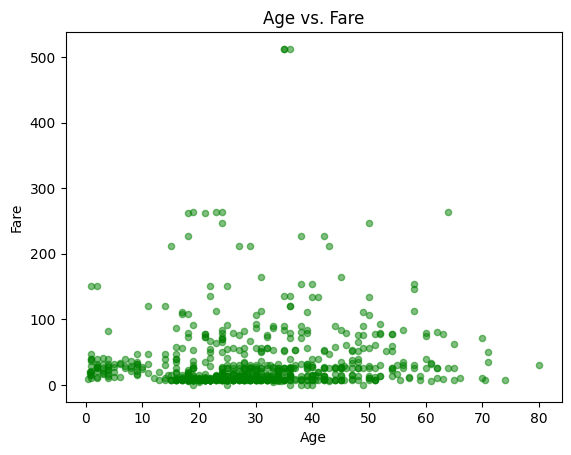

In [5]:
# Scatter plot of 'Age' vs. 'Fare'
df.plot.scatter(x='Age', y='Fare', alpha=0.5, color='green')
plt.title('Age vs. Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

### Box Plot

- Create a box plot of `Age` grouped by `Pclass`: `df.boxplot(column='Age', by='Pclass')`

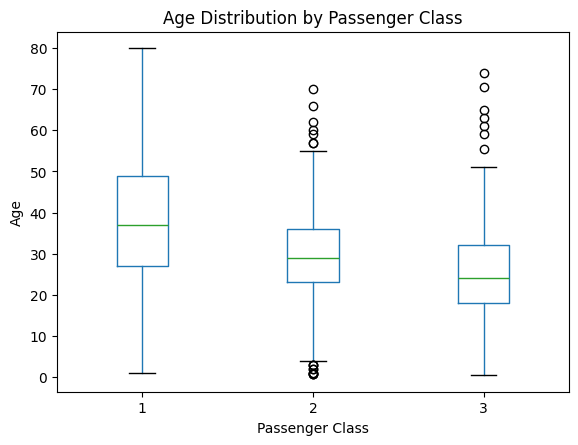

In [7]:
# Box plot of 'Age' by 'Pclass'
df.boxplot(column='Age', by='Pclass', grid=False)
plt.title('Age Distribution by Passenger Class')
plt.suptitle('')  # Remove the automatic 'Boxplot grouped by ...' title
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

## Exercise 

Go on - make some pretty plots from the penguins data - you know you want too!

<a id='conclusion'></a>
## 5. Conclusion

In this workshop, we've:

- Explored data loading and initial exploration with Pandas.
- Performed data manipulation tasks using Pandas DataFrames.
- Demonstrated how to perform equivalent operations using NumPy arrays.
- Utilized Pandas' native plotting functions for quick data visualization.

**Next Steps:**

- Practice with your own datasets to reinforce these concepts.
- Explore more advanced data manipulation techniques in Pandas and NumPy.
- Learn about data visualization libraries like Seaborn and Plotly for enhanced plots.

---

# Data Visualization with Pandas, Matplotlib, and Seaborn in Biology

Welcome to this workshop! In this session, we'll explore how to use **Pandas** for data manipulation and **Matplotlib**/**Seaborn** for plotting biological data. We'll cover:

- Loading and exploring biological datasets
- Data manipulation with Pandas
- Creating visualizations with Matplotlib
- Enhancing plots with Seaborn



## Table of Contents

1. [Introduction](#introduction)
2. [Loading Biological Data](#loading_data)
3. [Data Exploration with Pandas](#data_exploration)
4. [Visualizations with Matplotlib](#matplotlib_visualizations)
5. [Advanced Visualizations with Seaborn](#seaborn_visualizations)
6. [Case Study: Gene Expression Data](#case_study)
7. [Conclusion](#conclusion)

---

<a id='loading_data'></a>
## 1. Loading Biological Data

We'll begin by loading some example biological data into Pandas DataFrames.

### Dataset: Iris Flower Dataset

- Famous dataset in biology for classification.
- Contains measurements of sepal length, sepal width, petal length, petal width for three species of Iris.

In [ ]:
# Import necessary libraries
import pandas as pd

# Load the fish dataset from a URL:
url = "https://calmcode.io/static/data/fish.csv"
fish = pd.read_csv(url)

# Display the first few rows
fish.head()

<a id='data_exploration'></a>
## 2. Data Exploration with Pandas

Let's explore the dataset using Pandas.

In [ ]:
# Get basic information about the dataset
fish.info()

In [ ]:
# Get statistical summary
fish.describe()


### Distribution of Species

```python
fish['Species'].value_counts()
```

In [ ]:
# Get counts of each species
fish['Species'].value_counts()

<a id='matplotlib_visualizations'></a>
## 3. Visualizations with Matplotlib

We'll create basic plots using Matplotlib.

In [ ]:
# Import Matplotlib
import matplotlib.pyplot as plt
%matplotlib inline  

### Histogram of Fish Weight

```python
plt.hist(fish['Weight'], bins=15, color='green')
plt.xlabel('Fish weight (g)')
plt.ylabel('Frequency')
plt.title('Histogram of Fish Weight')
plt.show()
```

In [ ]:
# Histogram of Fish Weight
plt.hist(fish['Weight'], bins=15, color='green')
plt.xlabel('Fish weight (g)')
plt.ylabel('Frequency')
plt.title('Histogram of Fish Weight')
plt.show()

### Scatter Plot of Fish Length vs. Body Weight

```python
plt.scatter(fish['Weight'], fish['Length1'], color='blue')
plt.xlabel('Fish Weight (g)')
plt.ylabel('Fish Length (cm)')
plt.title('Fish Length vs Weight')
plt.show()
```

In [ ]:
# Scatter Plot of Fish Length vs. Body Weight
plt.scatter(fish['Weight'], fish['Length1'], color='blue')
plt.xlabel('Fish Weight (g)')
plt.ylabel('Fish Length (cm)')
plt.title('Fish Length vs Weight')
plt.show()

<a id='seaborn_visualizations'></a>
## 4. Advanced Visualizations with Seaborn

Seaborn builds on Matplotlib and provides a high-level interface for statistical graphics.

In [ ]:
# Import Seaborn
import seaborn as sns
sns.set(style='whitegrid')

### Boxplot of Sepal Length by Species

```python
sns.boxplot(x='Species', y='Length1', data=fish)
plt.title('Fish Length by Species')
plt.show()
```

In [ ]:
# Boxplot of Fish Length by Species
sns.boxplot(x='Species', y='Length1', data=fish)
plt.title('Fish Length by Species')
plt.show()

### Pairplot of All Variables

```python
sns.pairplot(fish, hue='Species')
plt.show()
```

In [ ]:
# Pairplot of All Variables
sns.pairplot(fish, hue='Species')
plt.show()

### Violin Plot of Petal Length by Species

```python
sns.violinplot(x='Species', y='Length1', data=fish, inner='quartile')
plt.title('Body Length Distribution by Species')
plt.show()
```

In [ ]:
# Violin Plot of Petal Length by Species
sns.violinplot(x='Species', y='Length1', data=fish, inner='quartile')
plt.title('Body Length Distribution by Species')
plt.show()

<a id='case_study'></a>
## 5. Case Study: Gene Expression Data

We'll apply these techniques to a gene expression dataset.

### Dataset: Differential Gene Expression

- Contains expression levels of genes under different conditions.
- Example data is generated for demonstration.

In [ ]:
# Generate sample gene expression data
import numpy as np

np.random.seed(0)
genes = [f'Gene_{i}' for i in range(1, 101)]
conditions = ['Control', 'Treatment']

data = {
    'gene': np.repeat(genes, len(conditions)),
    'condition': conditions * len(genes),
    'expression': np.random.randn(len(genes) * len(conditions)) + 5
}

gene_expression = pd.DataFrame(data)

# Display the first few rows
gene_expression.head()

## Exercise

### Visualize Expression Levels



In [ ]:
# Boxplot of Expression Levels


In [ ]:
# Violin Plot


In [ ]:
# Swarm Plot for a Subset of Genes


<a id='conclusion'></a>
## 6. Conclusion

We've:

- Learned how to load and explore biological datasets using Pandas.
- Created basic visualizations using Matplotlib.
- Enhanced our plots with Seaborn for statistical graphics.
- Applied these techniques to a gene expression dataset.

**Next Steps:**

- Practice with your own biological datasets.
- Explore more advanced plotting techniques in Seaborn and Matplotlib.
- Combine multiple plots to create comprehensive figures for publications.

---

# File Handling in Bioinformatics



## Introduction to File Handling


- Bioinformatics data is often stored in text formats (FASTA, CSV, TSV).


- Reading and writing files to process genomic and protein sequences.



## Reading FASTA Files


- Example of reading a FASTA file format for DNA sequences (but don't forget biopython!).


```python
def read_fasta(filename):
    """ Function to read a fasta file.
    >sequencename
    ATGCTGACTGATGCATG
    GTAGCCGTGTGCCTTT
    >sequencename2
    ATGCGTCGTGATGCG

    filename: the name of the file we wish to read
    """
    with open(filename, 'r') as file: # opens filename in read only mode with handle file
        sequences = {} # empty dictionary to store the sequences
        current_seq = '' # empty string to hold current line?
        for line in file: # reading each line of the file
            if line.startswith('>'): # we are looking at a sequence header
                if current_seq: # Checking if current_seq has any content
                    sequences[header] = current_seq
                    current_seq = ''
                header = line[1:].strip() # set the value of header to sequencename if >sequencename
            else: # we are looking at sequence data
                current_seq += line.strip() # Add the sequence data to the current_seq
        if current_seq: # If we now have sequence we will:
            sequences[header] = current_seq # Add our sequence to the dictionary
    return sequences # return the complete sequences dictionary®
print(read_fasta('example.fasta'))

```




## Writing Processed Data to CSV


- Saving processed gene expression data to CSV for analysis.


```python
import csv

# Sample data
genes = [{'gene': 'BRCA1', 'expression': 2.5}, {'gene': 'TP53', 'expression': 3.1}]

# Writing to CSV
with open('gene_expression.csv', 'w', newline='') as csvfile:
    fieldnames = ['gene', 'expression']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    for gene in genes:
        writer.writerow(gene)
```


# Exception Handling in Bioinformatics



## Importance of Exception Handling in Bioinformatics


- Bioinformatics data can contain errors or missing values.


- Handling these cases gracefully is essential.



## Handling File Not Found and Format Errors


- Using `try`, `except` to handle file-related errors in data loading.


### Example:


```python
try:
    with open('missing_file.fasta', 'r') as file:
        data = file.read()
except FileNotFoundError:
    print('File not found. Please check the file path.')
```


## Handling Data Type and Missing Value Errors


- Catching errors in numeric data conversion for gene expression data.


```python
data = ['3.1', '4.5', 'nan', '5.2']  # Example dataset
expression_values = []

for val in data:
    try:
        expression_values.append(float(val))
    except ValueError:
        print(f'Skipping invalid data point: {val}')

print('Processed values:', expression_values)
```


# Writing Stand-Alone Python Scripts: Best Practices

In this session, we'll cover:

- Writing stand-alone Python scripts
- Importance of code comments and documentation
- Significance of whitespace in Python coding

## Table of Contents

1. [Introduction](#introduction)
2. [Writing Stand-Alone Scripts](#writing_scripts)
3. [Importance of Comments](#importance_comments)
4. [Best Practices for Commenting Code](#commenting_best_practices)
5. [Whitespace in Python](#whitespace_python)
6. [Examples and Exercises](#examples_exercises)
7. [Conclusion](#conclusion)

---

<a id='writing_scripts'></a>
## 1. Writing Stand-Alone Scripts

### What is a Stand-Alone Script?

- A Python script that can be executed directly from the command line.
- Contains code that runs when the script is executed.
- Often includes a `main()` function and the `if __name__ == "__main__":` idiom.

### Basic Structure of a Stand-Alone Script

```python
#!/usr/bin/env python3

def main():
    # Your code here
    pass

if __name__ == "__main__":
    main()
```

- The shebang (`#!/usr/bin/env python3`) allows the script to be executed as a program.
- The `main()` function contains the code to be executed.
- The `if __name__ == "__main__":` block ensures `main()` runs when the script is executed directly.

### Example: Hello World Script

```python
#!/usr/bin/env python3

def main():
    print("Hello, World!")

if __name__ == "__main__":
    main()
```

- Save this code in a file named `hello_world.py`.
- Make it executable: `chmod +x hello_world.py`
- Run it from the command line: `./hello_world.py`

<a id='importance_comments'></a>
## 2. Importance of Comments

### Why Comment Your Code?

- **Readability**: Helps others (and yourself) understand the code.
- **Maintainability**: Easier to update and modify code in the future.
- **Collaboration**: Facilitates teamwork by explaining code logic.
- **Documentation**: Provides context and usage information.

### Types of Comments in Python

- **Inline Comments**: Explain specific lines or blocks of code.
  ```python
  x = x + 1  # Increment x by 1
  ```
- **Block Comments**: Provide detailed explanations for code sections.
  ```python
  # This function calculates the factorial of a number
  # using a recursive approach.
  def factorial(n):
      if n == 0:
          return 1
      else:
          return n * factorial(n - 1)
  ```
- **Docstrings**: Describe modules, classes, and functions.
  ```python
  def greet(name):
      """Return a greeting message for the given name."""
      return f"Hello, {name}!"
  ```

<a id='commenting_best_practices'></a>
## 3. Best Practices for Commenting Code

### Keep Comments Clear and Concise

- Use simple language.
- Be precise and to the point.

### Keep Comments Up-to-Date

- Update comments when code changes.
- Outdated comments can be misleading.

### Avoid Redundant Comments

- Don't comment on self-explanatory code.
- Example:
  ```python
  i = 0  # Set i to zero  # Redundant comment
  ```

### Use Docstrings for Documentation

- Describe the purpose, arguments, return values, and exceptions.
- Follows conventions like reStructuredText or Google style.

### Example: Well-Commented Function

```python
def fibonacci(n):
    """
    Calculate the nth Fibonacci number.

    Parameters:
    n (int): The position in the Fibonacci sequence.

    Returns:
    int: The nth Fibonacci number.
    """
    if n <= 0:
        raise ValueError("n must be a positive integer")
    elif n == 1:
        return 0  # First Fibonacci number is 0
    elif n == 2:
        return 1  # Second Fibonacci number is 1
    else:
        # Initialize first two numbers
        a, b = 0, 1
        # Compute subsequent numbers
        for _ in range(2, n):
            a, b = b, a + b
        return b
```

<a id='whitespace_python'></a>
## 4. Whitespace in Python

### Significance of Whitespace

- **Indentation**: Python uses indentation to define code blocks.
- **Readability**: Proper whitespace improves code readability.
- **Syntax Errors**: Incorrect whitespace can lead to errors.

### Indentation Rules

- Use consistent indentation (spaces or tabs).
- PEP 8 recommends 4 spaces per indentation level.

#### Correct Indentation:
```python
if x > 0:
    print("Positive number")
else:
    print("Non-positive number")
```

#### Incorrect Indentation:
```python
if x > 0:
print("Positive number")  # IndentationError
else:
    print("Non-positive number")
```

### Use of Blank Lines

- Separate functions and classes with two blank lines.
- Separate code within functions with blank lines to enhance readability.

### Whitespace Around Operators

- Use spaces around operators and after commas.

#### Good Practice:
```python
result = a + b
list = [1, 2, 3]
```

#### Bad Practice:
```python
result=a+b
list = [1,2,3]
```

<a id='examples_exercises'></a>
## 5. Examples and Exercises

### Example: Stand-Alone Script with Comments and Proper Whitespace

```python
#!/usr/bin/env python3

def is_prime(n):
    """
    Check if a number is a prime number.

    Parameters:
    n (int): The number to check.

    Returns:
    bool: True if n is prime, False otherwise.
    """
    if n <= 1:
        return False
    for i in range(2, int(n ** 0.5) + 1):
        if n % i == 0:
            return False
    return True

def main():
    """Main function to test prime checking."""
    number = 29  # Change this number to test other values
    if is_prime(number):
        print(f"{number} is a prime number.")
    else:
        print(f"{number} is not a prime number.")

if __name__ == "__main__":
    main()
```

### Exercise: Fix the Indentation and Add Comments

#### Code to Fix:
```python
def factorial(n):
if n == 0:
return 1
else:
return n * factorial(n -1)
```

#### Tasks:
- Correct the indentation errors.
- Add appropriate comments and a docstring.

In [ ]:
#### Solution:



<a id='conclusion'></a>
## 6. Conclusion

We've:

- Learned how to write stand-alone Python scripts.
- Understood the importance of commenting code and best practices.
- Explored the significance of whitespace in Python coding.

**Next Steps:**

- Practice writing your own stand-alone scripts.
- Review and refactor existing code to improve comments and whitespace usage.
- Explore more advanced scripting techniques and tools.

---


## Exercise:

Write a standalone python script that can process a data set from above and print to screen various summary stats and save to files the output.
